# Detección de Fraude con Tarjetas de Crédito — Proyecto MLOps
**Software Inteligente (UNMSM, Ciclo 9) — Semana 14**

El notebook se construye por fases, siguiendo el ciclo de vida de MLOps. Cada sección corresponde a una etapa y se amplía conforme avanza el proyecto:

- **Fase 1 — Data (sección actual):** exploración del dataset (EDA). Se cargan los datos, se revisa su calidad, y se analizan el desbalance de clases, el comportamiento del monto y las correlaciones con el fraude.
- **Fase 2 — Modeling:** entrenamiento y comparación de modelos *(se añadirá más adelante)*.
- **Fase 3 — Tracking con MLflow:** registro de experimentos y del modelo *(se añadirá más adelante)*.
- **Fase 4 — Deployment:** despliegue y validación del modelo *(se añadirá más adelante)*.

---
# FASE 1 — Análisis Exploratorio de Datos (EDA)

## 0. Configuración

Se importan las librerías utilizadas a lo largo del notebook y se prepara la carpeta `reports/`, donde se guardan los gráficos generados.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Estilo de gráficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Carpeta para guardar los gráficos que irán al informe (/reports)
REPORTS_DIR = 'reports'
os.makedirs(REPORTS_DIR, exist_ok=True)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga del dataset

Se carga el archivo `creditcard.csv`. La celda lo busca de forma automática: en entorno local se toma de la carpeta del proyecto; en Google Colab se monta el Drive y se lee desde ahí (al ejecutar, Colab solicita autorizar el montaje).

In [2]:
# Se detecta si el entorno de ejecución es Google Colab
try:
    import google.colab  # noqa
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

# Se busca el CSV en la carpeta del proyecto (entorno local)
rutas = ['creditcard.csv', 'data/creditcard.csv', '../creditcard.csv']
ruta_csv = next((r for r in rutas if os.path.exists(r)), None)

# Si el entorno es Colab y no se halló en local, se monta Google Drive y se lee desde ahí
if ruta_csv is None and EN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    rutas_drive = [
        '/content/drive/MyDrive/octavo/creditcard.csv',
        '/content/drive/MyDrive/creditcard.csv',
    ]
    ruta_csv = next((r for r in rutas_drive if os.path.exists(r)), None)

assert ruta_csv is not None, (
    'No se encontró creditcard.csv. En Colab debe ubicarse en Google Drive; '
    'en entorno local, en la carpeta del proyecto.'
)
print(f'Cargando desde: {ruta_csv}')
df = pd.read_csv(ruta_csv)
print('Dataset cargado.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando desde: /content/drive/MyDrive/octavo/creditcard.csv
Dataset cargado.


## 2. Descripción y calidad de los datos

Se revisan el tamaño del dataset y los tipos de dato, y se comprueba con código la existencia de valores nulos o filas duplicadas antes de continuar.

In [3]:
print(f'Filas x Columnas: {df.shape[0]:,} x {df.shape[1]}')
print(f'\nColumnas: {list(df.columns)}')
df.head()

Filas x Columnas: 284,807 x 31

Columnas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Tipos de datos y memoria
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
# ---- Valores nulos (demostrado con código) ----
nulos_totales = df.isnull().sum().sum()
print(f'Total de valores nulos en todo el dataset: {nulos_totales}')
if nulos_totales == 0:
    print('=> No hay valores faltantes. El dataset está completo.')
else:
    print(df.isnull().sum()[df.isnull().sum() > 0])

Total de valores nulos en todo el dataset: 0
=> No hay valores faltantes. El dataset está completo.


In [6]:
# ---- Filas duplicadas (demostrado con código) ----
n_dup = df.duplicated().sum()
print(f'Filas duplicadas exactas: {n_dup:,}')
print(f'Porcentaje del total: {n_dup / len(df) * 100:.3f}%')

Filas duplicadas exactas: 1,081
Porcentaje del total: 0.380%


In [7]:
# El análisis se realiza sobre el dataset sin duplicados exactos
filas_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Filas antes: {filas_antes:,}  ->  Filas después: {len(df):,}')
print(f'Duplicados eliminados: {filas_antes - len(df):,}')

Filas antes: 284,807  ->  Filas después: 283,726
Duplicados eliminados: 1,081


## 3. Distribución de la clase (`Class`)

Se cuantifican las transacciones fraudulentas y legítimas, en cantidad y en porcentaje, con el fin de dimensionar el desbalance del problema.

In [8]:
conteo = df['Class'].value_counts().sort_index()
porcentaje = df['Class'].value_counts(normalize=True).sort_index() * 100

resumen_clase = pd.DataFrame({
    'Clase': ['0 - Legítima', '1 - Fraude'],
    'Cantidad': conteo.values,
    'Porcentaje (%)': porcentaje.round(3).values
})
print(resumen_clase.to_string(index=False))

n_fraude = int(conteo[1]); n_legit = int(conteo[0])
print(f'\n=> 1 fraude por cada ~{n_legit // n_fraude} transacciones legítimas.')

       Clase  Cantidad  Porcentaje (%)
0 - Legítima    283253          99.833
  1 - Fraude       473           0.167

=> 1 fraude por cada ~598 transacciones legítimas.


/tmp/ipykernel_33522/3537669978.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, ax=axes[0], palette=['#2e86de', '#e74c3c'])
/tmp/ipykernel_33522/3537669978.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legítima (0)', 'Fraude (1)'])
/tmp/ipykernel_33522/3537669978.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, ax=axes[1], palette=['#2e86de', '#e74c3c'])
/tmp/ipykernel_33522/3537669978.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes

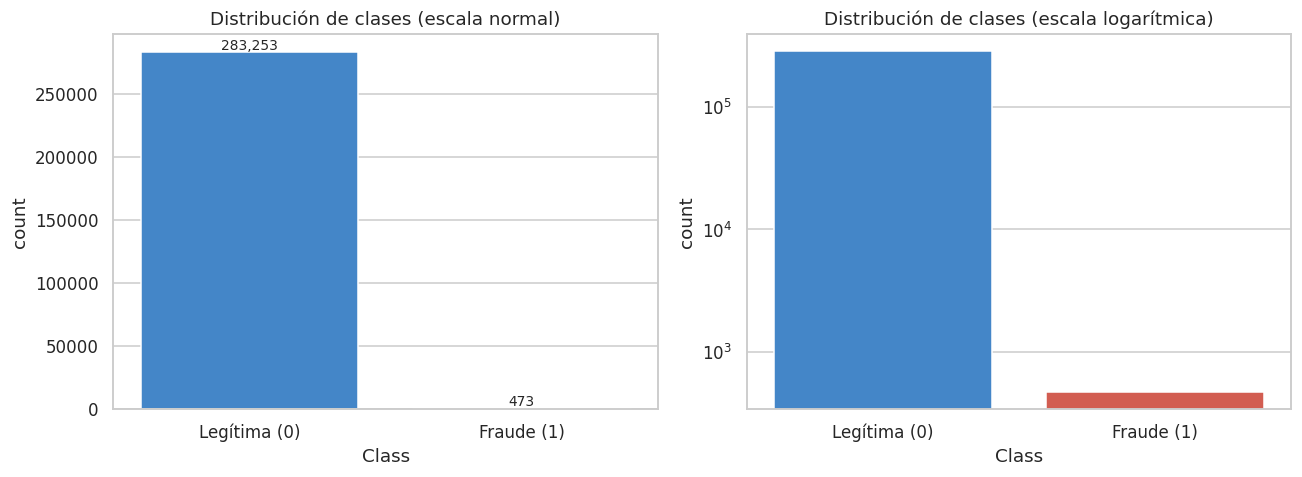

Gráfico guardado en /reports/01_desbalance_clases.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Escala normal (se ve lo extremo del desbalance)
sns.countplot(x='Class', data=df, ax=axes[0], palette=['#2e86de', '#e74c3c'])
axes[0].set_title('Distribución de clases (escala normal)')
axes[0].set_xticklabels(['Legítima (0)', 'Fraude (1)'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Escala logarítmica (permite ver la barra de fraude)
sns.countplot(x='Class', data=df, ax=axes[1], palette=['#2e86de', '#e74c3c'])
axes[1].set_yscale('log')
axes[1].set_title('Distribución de clases (escala logarítmica)')
axes[1].set_xticklabels(['Legítima (0)', 'Fraude (1)'])

plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/01_desbalance_clases.png', bbox_inches='tight')
plt.show()
print('Gráfico guardado en /reports/01_desbalance_clases.png')

## 4. Distribución del monto (`Amount`) por clase

Se compara el comportamiento del monto entre las transacciones legítimas y las fraudulentas, mediante estadísticas descriptivas, un boxplot y un histograma.

In [10]:
resumen_amount = df.groupby('Class')['Amount'].describe()[['mean', '50%', 'std', 'max']]
resumen_amount.index = ['Legítima (0)', 'Fraude (1)']
resumen_amount.columns = ['Media', 'Mediana', 'Desv. Est.', 'Máximo']
print('Estadísticas de Amount por clase:')
print(resumen_amount.round(2).to_string())

Estadísticas de Amount por clase:
               Media  Mediana  Desv. Est.    Máximo
Legítima (0)   88.41    22.00      250.38  25691.16
Fraude (1)    123.87     9.82      260.21   2125.87


/tmp/ipykernel_33522/1046767578.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0], palette=['#2e86de', '#e74c3c'])
/tmp/ipykernel_33522/1046767578.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legítima (0)', 'Fraude (1)'])


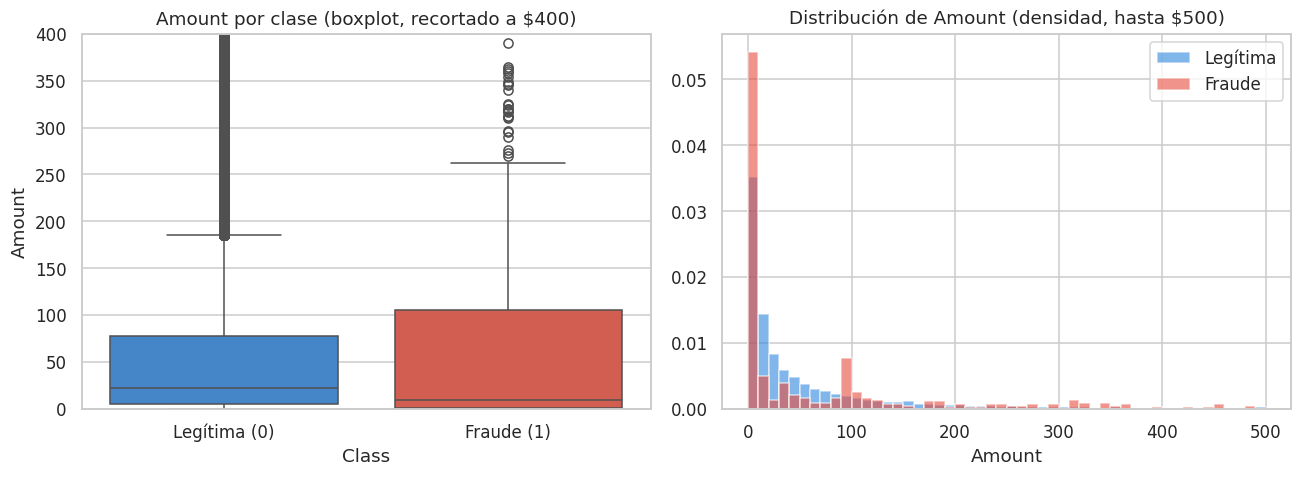

Gráfico guardado en /reports/02_amount_por_clase.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Boxplot de Amount por clase (recortamos eje Y para que sea legible)
sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0], palette=['#2e86de', '#e74c3c'])
axes[0].set_ylim(0, 400)
axes[0].set_title('Amount por clase (boxplot, recortado a $400)')
axes[0].set_xticklabels(['Legítima (0)', 'Fraude (1)'])

# Histogramas superpuestos
axes[1].hist(df[df.Class == 0]['Amount'], bins=50, range=(0, 500), alpha=0.6, label='Legítima', color='#2e86de', density=True)
axes[1].hist(df[df.Class == 1]['Amount'], bins=50, range=(0, 500), alpha=0.6, label='Fraude', color='#e74c3c', density=True)
axes[1].set_title('Distribución de Amount (densidad, hasta $500)')
axes[1].set_xlabel('Amount'); axes[1].legend()

plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/02_amount_por_clase.png', bbox_inches='tight')
plt.show()
print('Gráfico guardado en /reports/02_amount_por_clase.png')

## 5. Matriz de correlación

Se calcula la correlación entre todas las variables y se identifican las que más se relacionan con `Class`. Se muestra primero el mapa de calor completo y, a continuación, un ranking con las variables más correlacionadas con el fraude.

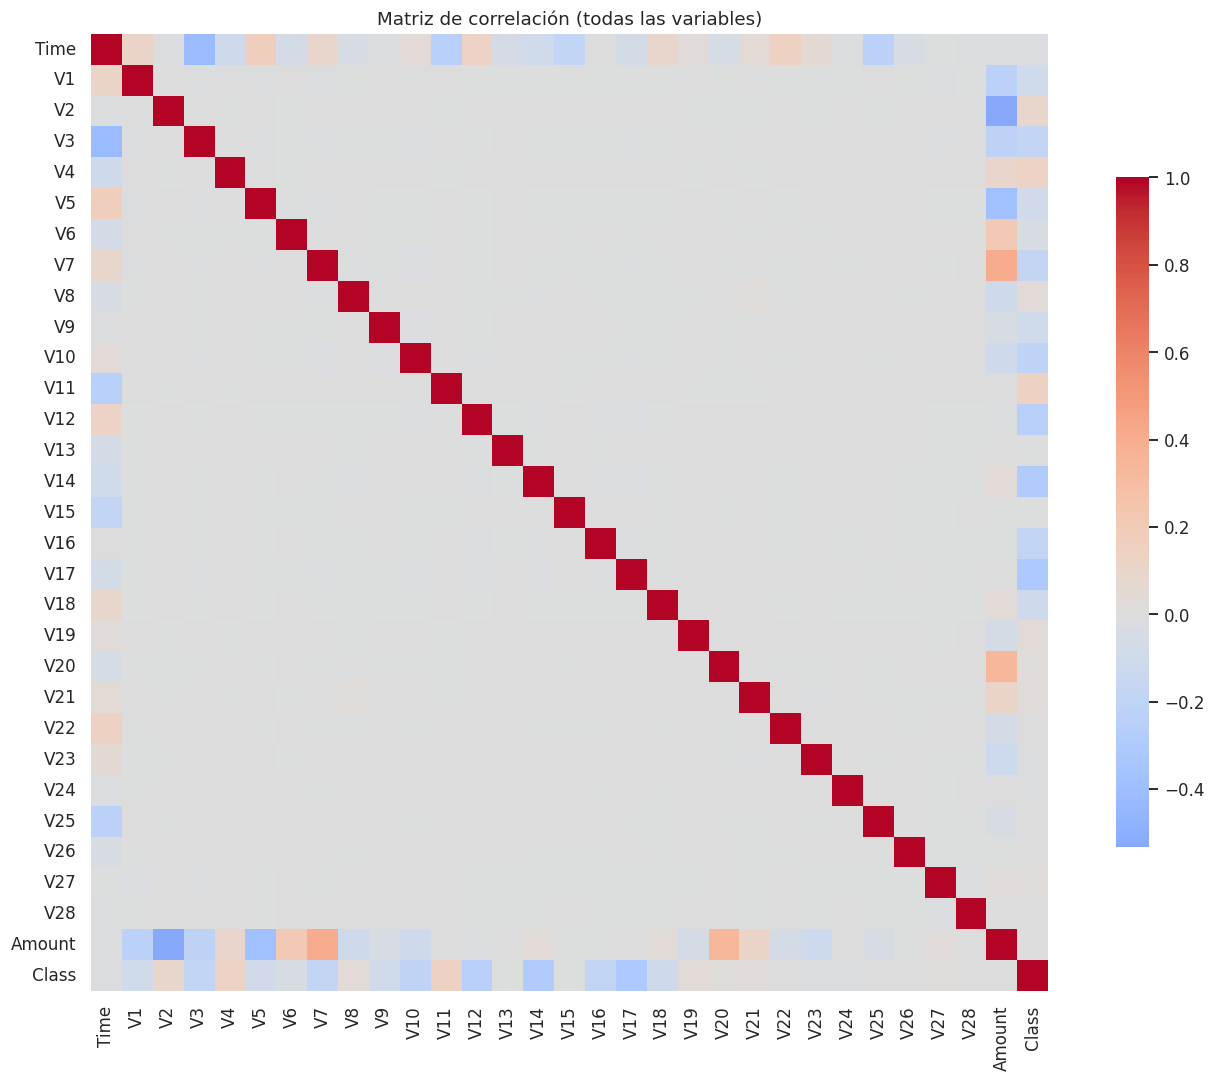

Gráfico guardado en /reports/03_matriz_correlacion.png


In [12]:
corr = df.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.7}, xticklabels=True, yticklabels=True)
plt.title('Matriz de correlación (todas las variables)')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/03_matriz_correlacion.png', bbox_inches='tight')
plt.show()
print('Gráfico guardado en /reports/03_matriz_correlacion.png')

Top 10 variables más correlacionadas con el fraude (Class):
V17   -0.313
V14   -0.293
V12   -0.251
V10   -0.207
V16   -0.187
V3    -0.182
V7    -0.172
V11    0.149
V4     0.129
V18   -0.105


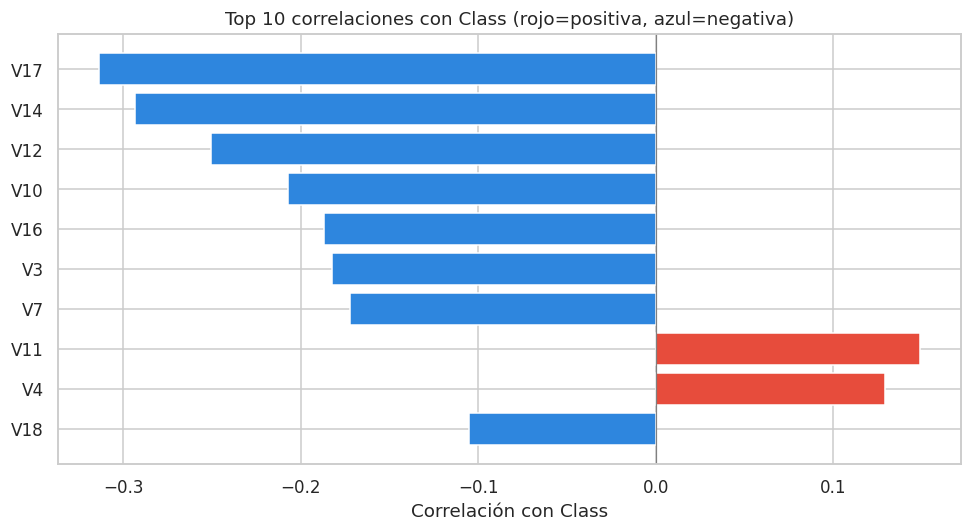

Gráfico guardado en /reports/04_top_correlaciones.png


In [13]:
# Ranking: variables más correlacionadas con Class (valor absoluto)
corr_class = corr['Class'].drop('Class').sort_values(key=abs, ascending=False)
print('Top 10 variables más correlacionadas con el fraude (Class):')
print(corr_class.head(10).round(3).to_string())

# Gráfico de barras del top
plt.figure(figsize=(9, 5))
top = corr_class.head(10)
colores = ['#e74c3c' if v > 0 else '#2e86de' for v in top.values]
plt.barh(top.index[::-1], top.values[::-1], color=colores[::-1])
plt.axvline(0, color='gray', lw=0.8)
plt.title('Top 10 correlaciones con Class (rojo=positiva, azul=negativa)')
plt.xlabel('Correlación con Class')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/04_top_correlaciones.png', bbox_inches='tight')
plt.show()
print('Gráfico guardado en /reports/04_top_correlaciones.png')